# 01 — Exploratory Data Analysis (EDA) — SignBridge

This notebook analyzes the processed SignBridge landmark dataset pre-processed in `00_Preprocessing.ipynb`.

The notebook:
- Loads processed train/validation/test arrays
- Examines class balance and participant splits
- Visualizes sequence length distributions
- Inspects normalization statistics
- Creates plots and tables for reporting
- Saves EDA outputs into the standardized `results/` directory


In [1]:
# ============================================================
# CELL 1 — Notebook Setup and Path Configuration
# ============================================================

from google.colab import drive

drive.mount('/content/drive')

import os
import json
import random
from collections import Counter

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Change this only if your project folder is somewhere else.
PROJECT_ROOT = '/content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge'

SRC_DIR = os.path.join(PROJECT_ROOT, 'src')

DATA_DIR = os.path.join(PROJECT_ROOT, 'data')
EXTERNAL_DIR = os.path.join(DATA_DIR, 'external')
PROCESSED_DIR = os.path.join(DATA_DIR, 'processed')

MODEL_DIR = os.path.join(PROJECT_ROOT, 'models')
CHECKPOINT_DIR = os.path.join(MODEL_DIR, 'checkpoints')
ONNX_DIR = os.path.join(MODEL_DIR, 'onnx')
LOGS_DIR = os.path.join(MODEL_DIR, 'logs')

RESULTS_DIR = os.path.join(PROJECT_ROOT, 'results')
GRAPH_DIR = os.path.join(RESULTS_DIR, 'graphs')
REPORT_DIR = os.path.join(RESULTS_DIR, 'reports')
TABLE_DIR = os.path.join(RESULTS_DIR, 'tables')

# Preprocessing output folder for this notebook
INPUT_DIR = PROCESSED_DIR

for folder in [
    SRC_DIR,
    DATA_DIR,
    EXTERNAL_DIR,
    PROCESSED_DIR,
    MODEL_DIR,
    CHECKPOINT_DIR,
    ONNX_DIR,
    LOGS_DIR,
    RESULTS_DIR,
    GRAPH_DIR,
    REPORT_DIR,
    TABLE_DIR,
]:
    os.makedirs(folder, exist_ok=True)

SEED = 42
random.seed(SEED)
np.random.seed(SEED)

print('Processed data dir:', INPUT_DIR)
print('Results dir:', RESULTS_DIR)


Mounted at /content/drive
Processed data dir: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge/data/processed
Results dir: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge/results


In [2]:
# ============================================================
# CELL 2 — Load Processed Arrays
# ============================================================

X_train = np.load(os.path.join(INPUT_DIR, 'X_train_norm.npz'))['data']
X_val   = np.load(os.path.join(INPUT_DIR, 'X_val_norm.npz'))['data']
X_test  = np.load(os.path.join(INPUT_DIR, 'X_test_norm.npz'))['data']

y_train = np.load(os.path.join(INPUT_DIR, 'y_train.npy'))
y_val   = np.load(os.path.join(INPUT_DIR, 'y_val.npy'))
y_test  = np.load(os.path.join(INPUT_DIR, 'y_test.npy'))

lengths_train = np.load(os.path.join(INPUT_DIR, 'lengths_train.npy'))
lengths_val   = np.load(os.path.join(INPUT_DIR, 'lengths_val.npy'))
lengths_test  = np.load(os.path.join(INPUT_DIR, 'lengths_test.npy'))

feat_mean = np.load(os.path.join(INPUT_DIR, 'feat_mean.npy'))
feat_std  = np.load(os.path.join(INPUT_DIR, 'feat_std.npy'))

print('X_train:', X_train.shape)
print('X_val:', X_val.shape)
print('X_test:', X_test.shape)


X_train: (55642, 96, 708)
X_val: (9291, 96, 708)
X_test: (11826, 96, 708)


In [3]:
# ============================================================
# CELL 3 — Load Metadata and Label Mapping
# ============================================================

with open(os.path.join(INPUT_DIR, 'metadata.json')) as f:
    metadata = json.load(f)

idx_to_sign = {
    int(k): v
    for k, v in metadata['label_to_word'].items()
}

sign_to_idx = {
    v: k
    for k, v in idx_to_sign.items()
}

N_CLASSES = len(idx_to_sign)

print('Number of classes:', N_CLASSES)

print('\nFirst 10 signs:')
for i in range(min(10, N_CLASSES)):
    print(i, idx_to_sign[i])


Number of classes: 250

First 10 signs:
0 TV
1 after
2 airplane
3 all
4 alligator
5 animal
6 another
7 any
8 apple
9 arm


In [4]:
# ============================================================
# CELL 4 — Dataset Shape Summary
# ============================================================

summary_df = pd.DataFrame({
    'Split': ['Train', 'Validation', 'Test'],
    'Samples': [len(X_train), len(X_val), len(X_test)],
    'Sequence Length': [X_train.shape[1], X_val.shape[1], X_test.shape[1]],
    'Features': [X_train.shape[2], X_val.shape[2], X_test.shape[2]],
})

display(summary_df)

summary_path = os.path.join(TABLE_DIR, 'dataset_summary.csv')
summary_df.to_csv(summary_path, index=False)

print('Saved:', summary_path)


,Split,Samples,Sequence Length,Features
0,Train,55642,96,708
1,Validation,9291,96,708
2,Test,11826,96,708


Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge/results/tables/dataset_summary.csv


Top 20 Train Classes


,label_idx,count,sign
159,135,281,listen
40,194,280,shhh
94,60,279,donkey
160,148,277,mouse
48,228,276,uncle
175,245,274,yesterday
119,111,273,hear
109,59,271,doll
55,239,270,who
1,23,270,bird



Top 20 Validation Classes


,label_idx,count,sign
154,31,57,brown
93,134,53,lips
151,229,53,underwear
106,148,53,mouse
64,158,52,nuts
178,98,52,goose
226,11,52,awake
48,122,51,icecream
13,47,51,closet
52,194,51,shhh



Top 20 Test Classes


,label_idx,count,sign
4,67,65,duck
48,37,62,carrot
26,200,61,sleepy
158,212,61,talk
67,149,60,mouth
41,59,60,doll
190,82,60,fireman
224,41,60,cheek
137,16,60,because
54,162,59,orange


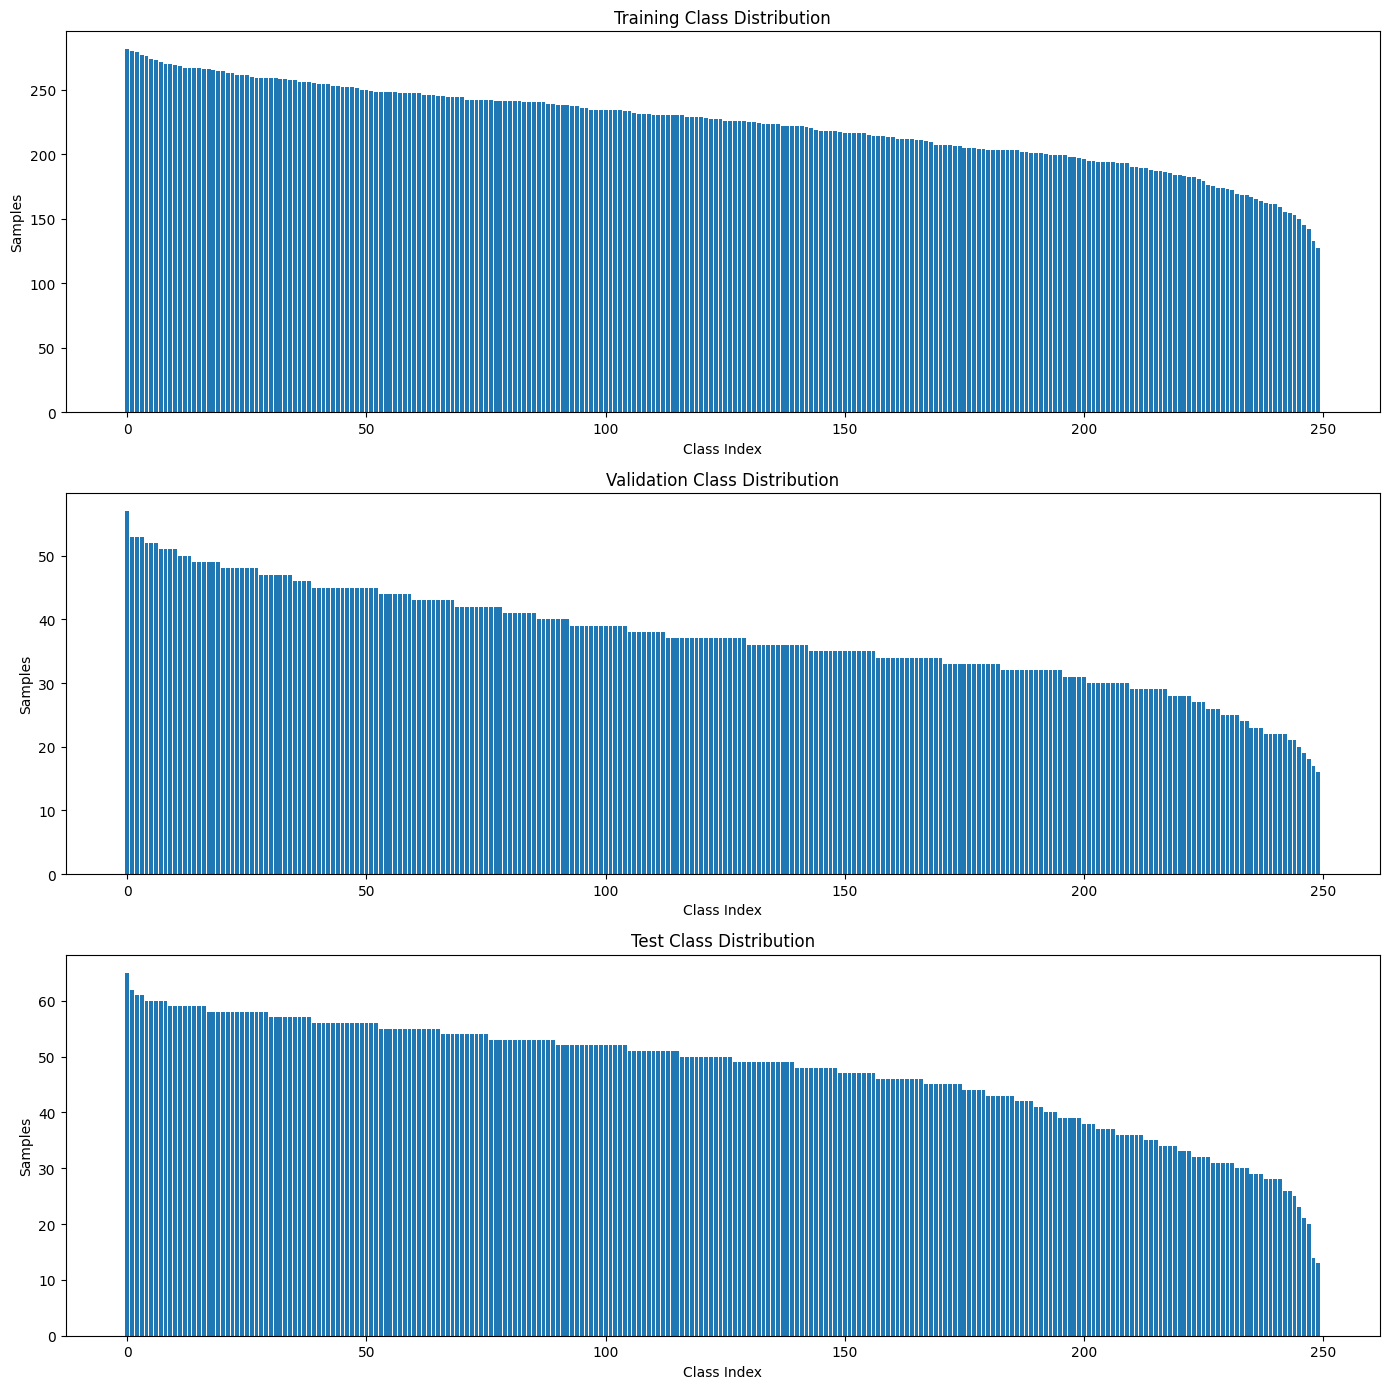

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge/results/graphs/class_distribution_all_splits.png


In [7]:
# ============================================================
# CELL 5 — Class Distribution Analysis
# ============================================================

# Count class frequencies for each split
train_counts = Counter(y_train)
val_counts   = Counter(y_val)
test_counts  = Counter(y_test)

# Create dataframes
train_df = pd.DataFrame({
    'label_idx': list(train_counts.keys()),
    'count': list(train_counts.values())
})
train_df['sign'] = train_df['label_idx'].map(idx_to_sign)
train_df = train_df.sort_values('count', ascending=False)

val_df = pd.DataFrame({
    'label_idx': list(val_counts.keys()),
    'count': list(val_counts.values())
})
val_df['sign'] = val_df['label_idx'].map(idx_to_sign)
val_df = val_df.sort_values('count', ascending=False)

test_df = pd.DataFrame({
    'label_idx': list(test_counts.keys()),
    'count': list(test_counts.values())
})
test_df['sign'] = test_df['label_idx'].map(idx_to_sign)
test_df = test_df.sort_values('count', ascending=False)

# Display top classes
print("Top 20 Train Classes")
display(train_df.head(20))

print("\nTop 20 Validation Classes")
display(val_df.head(20))

print("\nTop 20 Test Classes")
display(test_df.head(20))

# ============================================================
# Plot distributions
# ============================================================

fig, axes = plt.subplots(3, 1, figsize=(14, 14))

# Train
axes[0].bar(
    range(len(train_df)),
    train_df['count']
)
axes[0].set_title('Training Class Distribution')
axes[0].set_xlabel('Class Index')
axes[0].set_ylabel('Samples')

# Validation
axes[1].bar(
    range(len(val_df)),
    val_df['count']
)
axes[1].set_title('Validation Class Distribution')
axes[1].set_xlabel('Class Index')
axes[1].set_ylabel('Samples')

# Test
axes[2].bar(
    range(len(test_df)),
    test_df['count']
)
axes[2].set_title('Test Class Distribution')
axes[2].set_xlabel('Class Index')
axes[2].set_ylabel('Samples')

plt.tight_layout()

class_plot_path = os.path.join(
    GRAPH_DIR,
    'class_distribution_all_splits.png'
)

plt.savefig(class_plot_path, dpi=150)
plt.show()

print('Saved:', class_plot_path)

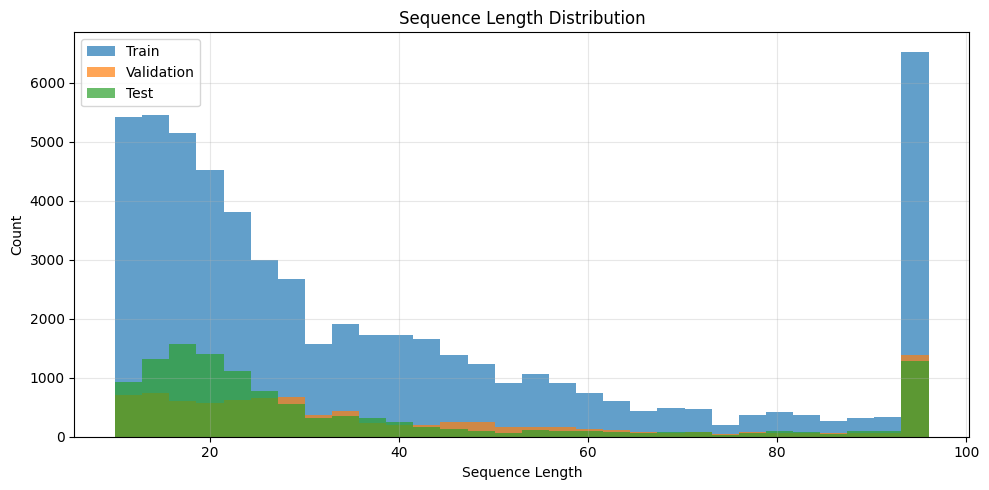

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge/results/graphs/sequence_length_distribution.png


In [ ]:
# ============================================================
# CELL 6 — Sequence Length Distribution
# ============================================================

plt.figure(figsize=(10, 5))

plt.hist(lengths_train, bins=30, alpha=0.7, label='Train')
plt.hist(lengths_val, bins=30, alpha=0.7, label='Validation')
plt.hist(lengths_test, bins=30, alpha=0.7, label='Test')

plt.xlabel('Sequence Length')
plt.ylabel('Count')
plt.title('Sequence Length Distribution')

plt.legend()
plt.grid(True, alpha=0.3)

plt.tight_layout()

length_plot_path = os.path.join(GRAPH_DIR, 'sequence_length_distribution.png')

plt.savefig(length_plot_path, dpi=150)
plt.show()

print('Saved:', length_plot_path)


Feature mean statistics:
Min: -0.028395787
Max: 0.2220689
Mean: 0.05139401

Feature std statistics:
Min: 0.0019216541
Max: 1.0
Mean: 0.11075116


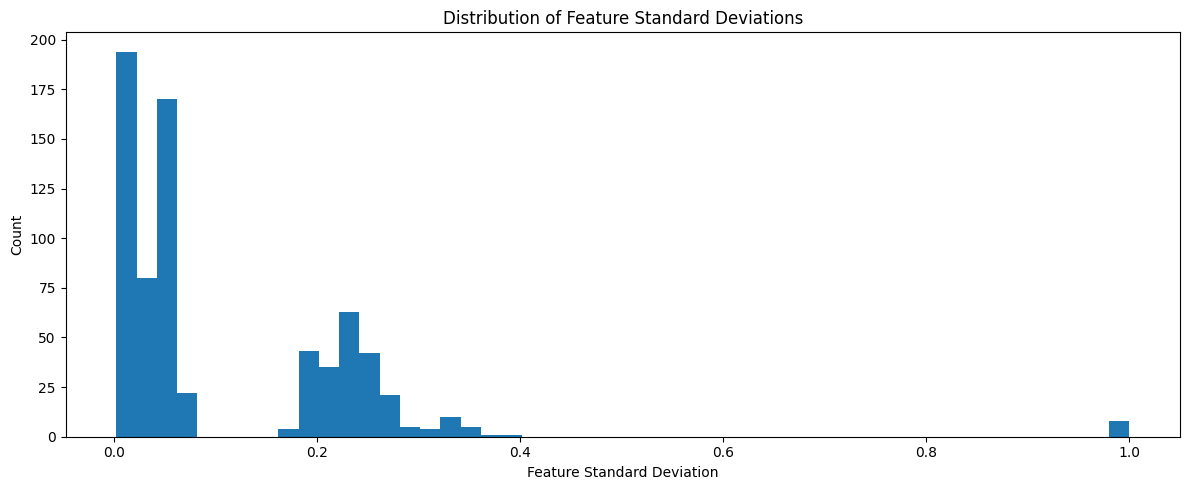

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge/results/graphs/feature_std_distribution.png


In [ ]:
# ============================================================
# CELL 7 — Feature Normalization Inspection
# ============================================================

print('Feature mean statistics:')
print('Min:', feat_mean.min())
print('Max:', feat_mean.max())
print('Mean:', feat_mean.mean())

print('\nFeature std statistics:')
print('Min:', feat_std.min())
print('Max:', feat_std.max())
print('Mean:', feat_std.mean())

plt.figure(figsize=(12, 5))

plt.hist(feat_std, bins=50)

plt.xlabel('Feature Standard Deviation')
plt.ylabel('Count')
plt.title('Distribution of Feature Standard Deviations')

plt.tight_layout()

std_plot_path = os.path.join(GRAPH_DIR, 'feature_std_distribution.png')

plt.savefig(std_plot_path, dpi=150)
plt.show()

print('Saved:', std_plot_path)


In [ ]:
# ============================================================
# CELL 8 — Missing Value Inspection
# ============================================================

print('Checking for NaNs...')

print('Train NaNs:', np.isnan(X_train).sum())
print('Validation NaNs:', np.isnan(X_val).sum())
print('Test NaNs:', np.isnan(X_test).sum())

print('\nChecking for infinities...')

print('Train infs:', np.isinf(X_train).sum())
print('Validation infs:', np.isinf(X_val).sum())
print('Test infs:', np.isinf(X_test).sum())


Checking for NaNs...
Train NaNs: 0
Validation NaNs: 0
Test NaNs: 0

Checking for infinities...
Train infs: 0
Validation infs: 0
Test infs: 0


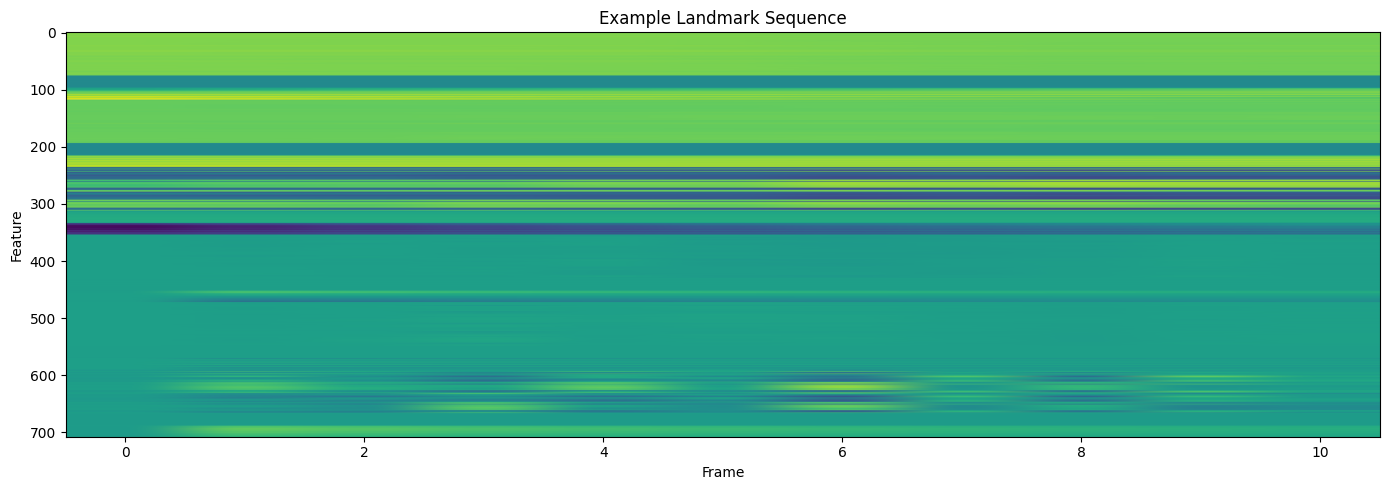

Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge/results/graphs/example_landmark_sequence.png


In [ ]:
# ============================================================
# CELL 9 — Example Landmark Visualization
# ============================================================

sample_idx = 0

sample = X_train[sample_idx]
sample_length = lengths_train[sample_idx]

plt.figure(figsize=(14, 5))

plt.imshow(
    sample[:sample_length].T,
    aspect='auto'
)

plt.xlabel('Frame')
plt.ylabel('Feature')
plt.title('Example Landmark Sequence')

plt.tight_layout()

sample_plot_path = os.path.join(GRAPH_DIR, 'example_landmark_sequence.png')

plt.savefig(sample_plot_path, dpi=150)
plt.show()

print('Saved:', sample_plot_path)


In [ ]:
# ============================================================
# CELL 10 — Save Final EDA Summary
# ============================================================

summary = {
    'n_classes': int(N_CLASSES),
    'train_samples': int(len(X_train)),
    'val_samples': int(len(X_val)),
    'test_samples': int(len(X_test)),
    'sequence_length': int(X_train.shape[1]),
    'n_features': int(X_train.shape[2]),
}

summary_path = os.path.join(REPORT_DIR, 'eda_summary.json')

with open(summary_path, 'w') as f:
    json.dump(summary, f, indent=2)

print(json.dumps(summary, indent=2))
print('Saved:', summary_path)


{
  "n_classes": 250,
  "train_samples": 55642,
  "val_samples": 9291,
  "test_samples": 11826,
  "sequence_length": 96,
  "n_features": 708
}
Saved: /content/drive/MyDrive/UChicago/Masters/Spring/ADSP 31018/SignBridge/results/reports/eda_summary.json
